# Import Basic Libraries

> Like numpy, pandas, matplotlib, seaborn and filter warnings

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Loading DataSet

> We have the data in .txt file not in csv file

> The row values are separated by ; so we will also seperate it using columns

> Its txt file so we have to give me columns name by ourself as well

> In end we will check wheter the changes applies on the data or not

In [39]:
df: pd.DataFrame = pd.read_csv(
    'train.txt',
    sep=';',
    header=None,
    names=['text', 'emotions']
)

In [40]:
df.head()

,text,emotions
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


# Check Null Values

> Null values can harm our ML model alot

> It can reduce model's accuracy becuase ML models cant process it we will get error like: **ValueError: Input contains NaN**

In [41]:
df.isna().sum() # No null values detected!

,0
text,0
emotions,0


# Check (n) Unique Emotion Values

> We will check that how much unique values are there in emotions

> We will the actual labels(values) as well of nunique emotions

In [42]:
df['emotions'].unique()

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)

In [43]:
df['emotions'].nunique()

6

# Checking count of each unique emotion value

> Checking the count of each unique emotion value will reveal the class distribution in our training dataset. This helps us identify which emotions are overrepresented or underrepresented.

> Visualizing these counts will also provide better intuition about our emotion feature (the independent variable or X) and help us understand its overall structure.


In [44]:
df['emotions'].value_counts()

,count
emotions,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


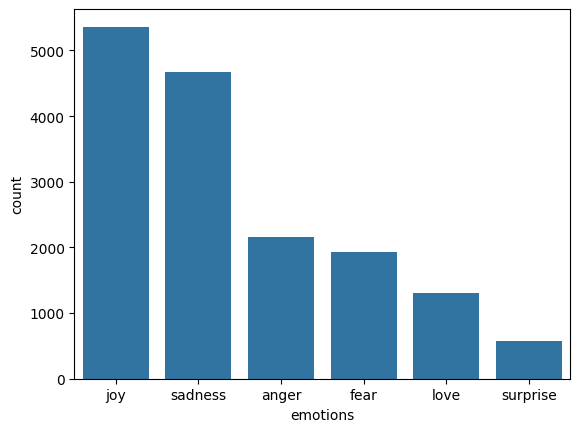

In [45]:
order = df['emotions'].value_counts().index

sns.countplot(x=df['emotions'], order=order)
plt.show()

# Label Encoding - Converting Text To Numbers

# What this code does:

> Finds all unique emotions in the dataset using .unique()

> Assigns a number (0, 1, 2, ...) to each unique emotion using a loop

> Replaces text labels with numbers using .map() so the model can understand them

# Why we do this:

> Machine Learning models work with numbers, not text - they can't process strings like "happy" or "sad"

> Keeps the original meaning - same emotions get the same number, different emotions get different number

In [46]:
emotions_number: dict[str, int] = {}
for i, emotion in enumerate(df['emotions'].unique()):
    emotions_number[emotion] = i

In [47]:
df['emotions'] = df['emotions'].map(emotions_number)

In [50]:
df['emotions'].head()

,emotions
0,0
1,0
2,1
3,2
4,1


# Data Cleaning

> This is the train.txt file dataset and in 1_Emotion_Tracker.ipynb i already checked all the text puntuations, stop words, acsii(emojis), digits and lower case

> We will just lower the text and remove the stop words nothing else because this is mainly for letting you know how TF - IDF works in code  thats why

> We will use NLTK library https://www.nltk.org/ for and i have mentioned the nltk.download('package_name') for our stop_word and word_tokenize

In [51]:
import nltk

# Download the most commonly used resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [52]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [55]:
stop_words = set(stopwords.words('english')) # This is important
# it tell for which language you needs stopwords

from typing import List

def clean_documents(text: str) -> str:
  try:
    if not text:
      return ""

    if not isinstance(text, str):
      text = str(text)

    text: str = text.lower()
    words: List[str] = word_tokenize(text)

    return ' '.join([word for word in words if not word in stop_words])

  except Exception as err:
    raise RuntimeError(f"\nError coming while cleaning documents due to: {err}\n") from err

In [56]:
df['text'] = df['text'].apply(clean_documents)

In [57]:
df['text'].head()

,text
0,didnt feel humiliated
1,go feeling hopeless damned hopeful around some...
2,im grabbing minute post feel greedy wrong
3,ever feeling nostalgic fireplace know still pr...
4,feeling grouchy


# Train Test Split

> We will perform a train-test split, which we've done many times throughout the course. A quick revision: some data from our dataset will be used for training the model, and some will be reserved for testing its performance. I generally use an 80/20 split throughout the course, so I'll keep it consistent here — 80% for training and 20% for testing.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['emotions'],
    test_size=0.2,
    random_state=42
)

# Performing TF-IDF & Creating MultinomialNB (Naive Bayes) & Logistic Regression Model

> Now that we have split our data into training and testing sets, we will convert our text data into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency). This will transform each document into a vector of numbers representing the importance of each word.

> After vectorizing our text data, we will train a Multinomial Naive Bayes classifier, which is particularly well-suited for text classification tasks like emotion detection. Naive Bayes works well with high-dimensional sparse data, making it an excellent choice for TF-IDF features.

> We will fit the TF-IDF vectorizer on the training data only (to prevent data leakage) and then transform both the training and testing sets. Finally, we'll train the model on the training data and evaluate its performance on the test data.

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

bow_vectorizer = CountVectorizer()

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

pred_bow = nb_model.predict(X_test_bow)

print(f"Accuracy: {accuracy_score(y_test, pred_bow)}")
print(f"Confusion Matrix: \n{confusion_matrix(y_test, pred_bow)}")
print(f"Classification Report: \n{classification_report(y_test, pred_bow)}")

Accuracy: 0.7678125
Confusion Matrix: 
[[899   8   3   0   4  32]
 [ 87 271   0   0  13  56]
 [ 51   6  78   0   4 157]
 [ 40   0   1   6  17  49]
 [ 87  15   0   0 226  69]
 [ 36   4   2   0   2 977]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.75      0.95      0.84       946
           1       0.89      0.63      0.74       427
           2       0.93      0.26      0.41       296
           3       1.00      0.05      0.10       113
           4       0.85      0.57      0.68       397
           5       0.73      0.96      0.83      1021

    accuracy                           0.77      3200
   macro avg       0.86      0.57      0.60      3200
weighted avg       0.80      0.77      0.74      3200



In [87]:
tfidf = TfidfVectorizer(
    max_features=10000,          # More features = better performance
    ngram_range=(1, 3),          # Unigrams + Bigrams + Trigrams
    stop_words='english',
    sublinear_tf=True,           # Better weighting (1 + log(tf))
    use_idf=True,
    smooth_idf=True,
    norm='l2'                    # L2 normalization
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

nb2_model = MultinomialNB()
nb2_model.fit(X_train_tfidf, y_train)

pred_tfidf = nb2_model.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, pred_tfidf)}")
print(f"Confusion Matrix: \n{confusion_matrix(y_test, pred_tfidf)}")
print(f"Classification Report: \n{classification_report(y_test, pred_tfidf)}")

Accuracy: 0.6609375
Confusion Matrix: 
[[ 883    0    0    0    2   61]
 [ 145  123    0    0    2  157]
 [  49    1    9    0    1  236]
 [  40    0    0    1    3   69]
 [ 137    8    0    0   88  164]
 [  10    0    0    0    0 1011]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.70      0.93      0.80       946
           1       0.93      0.29      0.44       427
           2       1.00      0.03      0.06       296
           3       1.00      0.01      0.02       113
           4       0.92      0.22      0.36       397
           5       0.60      0.99      0.74      1021

    accuracy                           0.66      3200
   macro avg       0.86      0.41      0.40      3200
weighted avg       0.76      0.66      0.58      3200



In [88]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 116049 stored elements and shape (12800, 13359)>

In [89]:
X_test_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 26934 stored elements and shape (3200, 13359)>

In [90]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()  # Preserves sparsity!
X_train_scaled = scaler.fit_transform(X_train_tfidf)
X_test_scaled = scaler.transform(X_test_tfidf)

In [91]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    penalty='elasticnet',        # Best of both L1 + L2
    C=0.5,                       # Tuned for best performance
    solver='saga',               # Best for elasticnet + large data
    max_iter=2000,               # Ensure convergence
    n_jobs=-1,                   # Use ALL CPU cores
    class_weight='balanced',     # Handle imbalance automatically
    random_state=42,
    tol=1e-4,                    # Stricter tolerance for better convergence
    l1_ratio=0.5                 # 50% L1, 50% L2
)

lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

In [95]:
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8875

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       946
           1       0.87      0.91      0.89       427
           2       0.74      0.96      0.83       296
           3       0.64      0.92      0.76       113
           4       0.87      0.83      0.85       397
           5       0.94      0.88      0.91      1021

    accuracy                           0.89      3200
   macro avg       0.84      0.90      0.86      3200
weighted avg       0.90      0.89      0.89      3200



# CountVectorizer vs TF-IDF vs Logistic Regression

>CountVectorizer with Naive Bayes gave 76.8% accuracy, while TF-IDF with Naive Bayes dropped to 66.1%, showing that better preprocessing doesn't always guarantee better results.

>However, when TF-IDF was combined with Logistic Regression, accuracy jumped to 88.75%, proving that the choice of model matters just as much as the preprocessing technique.

>The best model performed exceptionally well on sadness and joy, while love and surprise were more challenging to classify correctly.

>The key takeaway is that there is no single best approach in machine learning. The right combination of vectorizer and model depends on your specific data and task. Always experiment, compare multiple approaches, and let the results guide your decisions.

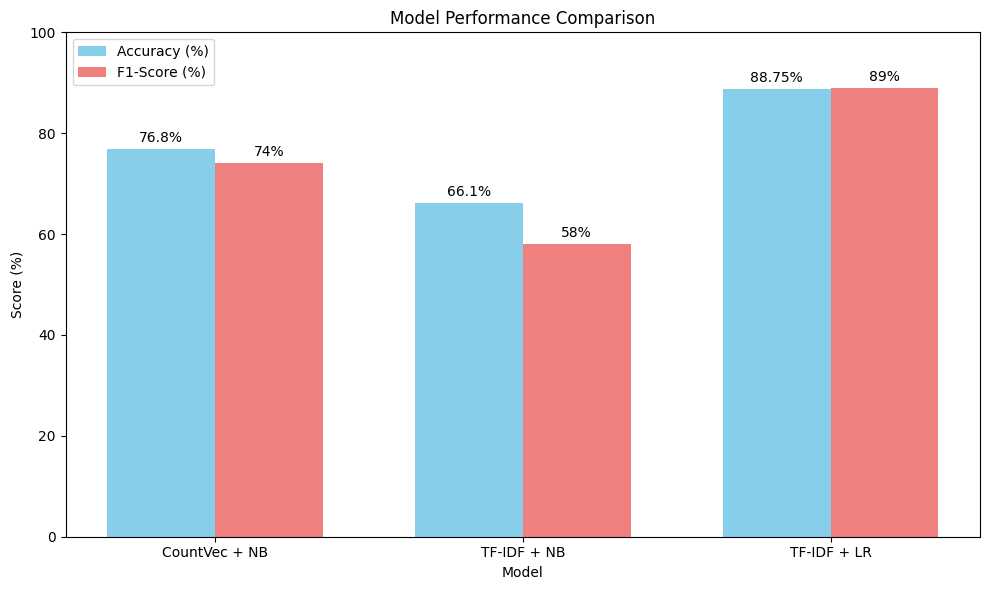

In [96]:
# I take this code from Deepseek and it working good so for time consuming
# and boring task use ai to save your time

# Results
models = ['CountVec + NB', 'TF-IDF + NB', 'TF-IDF + LR']
accuracy = [76.8, 66.1, 88.75]
f1_weighted = [74, 58, 89]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy (%)', color='skyblue')
bars2 = ax.bar(x + width/2, f1_weighted, width, label='F1-Score (%)', color='lightcoral')

ax.set_xlabel('Model')
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 100)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()